# Background

This Jupyter Notebook is focused on Exploratory Data Analysis (EDA) of the testing dataset of this research. This dataset was provided at UNLP 2025 Shared Task and consists of Ukrainian Telegram posts annotated for the presence of ten manipulation techniques. The goal is to analyze the dataset’s structure, distribution, and key characteristics to gain insights into different manipulation techniques and their linguistic attributes.


# Content

- **Setup Preparation**  
  - Importing required libraries  
  - Defining constants and paths  
  - Loading the dataset  
  - Initial data overview (shape, data types, missing values, etc.)  

- **Exploratory Data Analysis (EDA)**  
  - Language distribution analysis  
  - Manipulated vs. non-manipulated text distribution  
  - Text length analysis (word count per language)

- **Manipulative Techniques Analysis**  
  - Overall occurrences of manipulation techniques  
  - Distribution of techniques by language (Ukrainian vs. Russian)  
  - Co-occurrence analysis of manipulative techniques  

- **Named Entity Recognition (NER)**  
  - Setting up spaCy for NER  
  - Preprocessing text for NER  
  - NER on manipulative vs. non-manipulative text  
  - Comparison of named entities across manipulation techniques and languages

- **Sentiment Analysis**  
  - Using transformer-based models for sentiment analysis  
  - Comparing sentiment scores for manipulated and non-manipulated texts  
  - Comparing sentiment scores for different manipulation techniques

## Imports

In [1]:
import numpy as np
import os
import pandas as pd
import seaborn as sns
from collections import Counter
import warnings
import re
import spacy
import emoji
import ast
from langdetect import detect
from transformers import pipeline

import matplotlib.pyplot as plt

/Users/k_akhynko/Desktop/work/thesis/manipulative-narrative-detection/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings("ignore")

## Constants

In [3]:
TEST_PATH = "../data/"
TEST_NAME = "test.csv"

## Load and modify test data

In [4]:
df = pd.read_csv(os.path.join(TEST_PATH, TEST_NAME))
df.head()

,id,content,techniques,trigger_words
0,521cd2e8-dd9f-42c4-98ba-c0c8890ff1ba,"Они просрали нашу технику, положили кучу людей...","['fud', 'loaded_language']","[(0, 12), (27, 46), (48, 71), (131, 162), (164..."
1,9b2a61e4-d14e-4ff7-b304-e73d720319bf,❗️\nКитай предлагает отдать оккупированные тер...,['loaded_language'],"[(374, 425)]"
2,f0f1c236-80a8-4d25-b30c-a420a39be632,Сегодня будет ровно 6 месяцев с этого обещания...,['loaded_language'],"[(0, 127)]"
3,31ea05ba-2c2b-4b84-aba7-f3cf6841b204,⚡️\nІзраїль вперше у світі збив балістичну рак...,[],NaN
4,a79e13ec-6d9a-40b5-b54c-7f4f743a7525,Склав невелику навчально-методичну таблицю на ...,['loaded_language'],"[(87, 103), (127, 136), (170, 189), (204, 255)..."


In [5]:
print("Data types in content column:", Counter(df['content'].map(type)))
print("Data types in trigger_words column:", Counter(df['trigger_words'].map(type)))
print("Data types in techniques column:", Counter(df['techniques'].map(type)))

Data types in content column: Counter({<class 'str'>: 5735})
Data types in trigger_words column: Counter({<class 'str'>: 3907, <class 'float'>: 1828})
Data types in techniques column: Counter({<class 'str'>: 5735})


In [6]:
df['trigger_words'] = df['trigger_words'].apply(lambda x: x if isinstance(x, str) else "[]")

In [7]:
df['trigger_words'] = df['trigger_words'].apply(ast.literal_eval)
df['techniques'] = df['techniques'].apply(ast.literal_eval)

In [12]:
def detect_lang(text):
    try:
        return detect(text)
    except:
        return 'unknown'

df['lang'] = df['content'].apply(detect_lang)

In [14]:
df_ukru = df[df['lang'].isin(['uk', 'ru'])]

## Basic exploration

In [15]:
print("Dataset shape:", df.shape)

Dataset shape: (5735, 5)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5735 entries, 0 to 5734
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             5735 non-null   object
 1   content        5735 non-null   object
 2   techniques     5735 non-null   object
 3   trigger_words  5735 non-null   object
 4   lang           5735 non-null   object
dtypes: object(5)
memory usage: 224.2+ KB


In [17]:
df['manipulative'] = df['techniques'].apply(lambda x: True if len(x)>0 else False)

In [18]:
print("Number of manipulated texts:", df['manipulative'].sum(), "out of", df.shape[0])
print("Number of manipulated texts in Ukrainian:", df[df['lang']=='uk']['manipulative'].sum(), "out of", df[df['lang']=='uk'].shape[0])
print("Number of manipulated texts in Russian:", df[df['lang']=='ru']['manipulative'].sum(), "out of", df[df['lang']=='ru'].shape[0])

Number of manipulated texts: 3907 out of 5735
Number of manipulated texts in Ukrainian: 1928 out of 3130
Number of manipulated texts in Russian: 1972 out of 2595


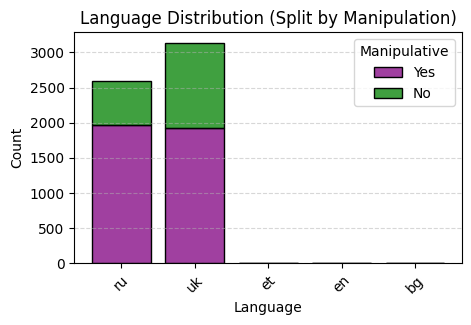

In [19]:
plt.figure(figsize=(5, 3))

sns.histplot(
    data=df, x="lang", hue="manipulative", multiple="stack", shrink=0.8,
    palette={0: "green", 1: "purple"}, discrete=True
)

plt.title("Language Distribution (Split by Manipulation)")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Manipulative", labels=["Yes", "No"], bbox_to_anchor=(1, 1))
plt.show()

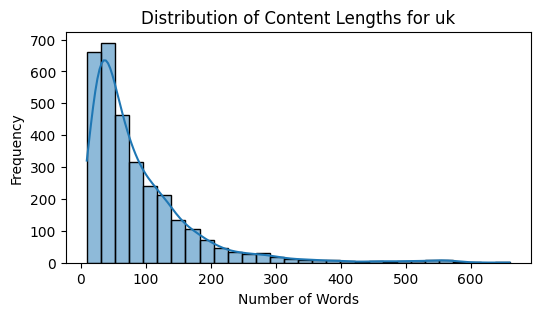

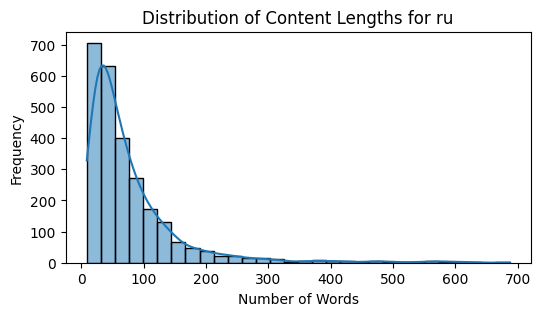

In [20]:
for lang in ['uk', 'ru']:
    content_length = df[df['lang'] == lang]['content'].apply(lambda x: len(str(x).split()))
    plt.figure(figsize=(6, 3))
    sns.histplot(content_length, bins=30, kde=True)
    plt.title(f"Distribution of Content Lengths for {lang}")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    # plt.ylim(0, 500)
    plt.show()

## Manipulative techniques analysis

In [23]:
# Number of occurrences of each technique
technique_counts = Counter([tech for sublist in df['techniques'] for tech in sublist])
technique_counts

Counter({'loaded_language': 2959,
         'cherry_picking': 768,
         'glittering_generalities': 723,
         'euphoria': 695,
         'cliche': 695,
         'fud': 576,
         'appeal_to_fear': 449,
         'bandwagon': 236,
         'whataboutism': 235,
         'straw_man': 207})

In [24]:
print("Number of manipulative techniques:", len(technique_counts))

Number of manipulative techniques: 10


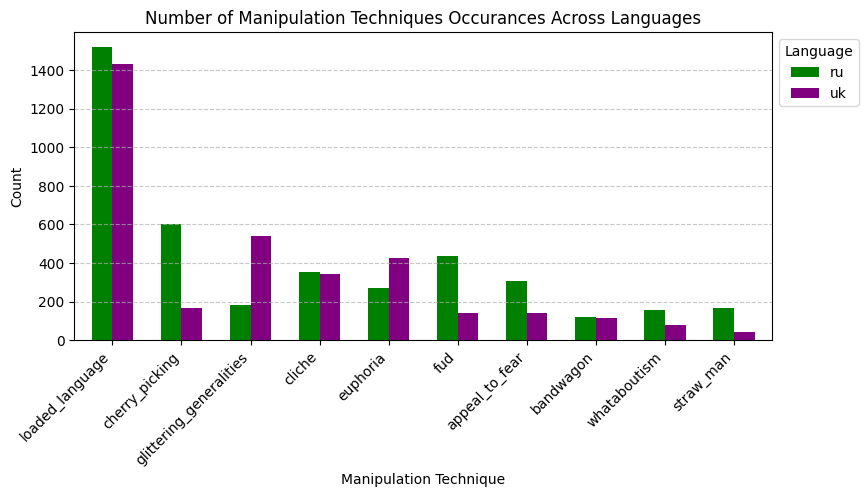

In [25]:
# Number of occurrences of each technique per language
technique_counts_lang = []
for lang in df_ukru['lang'].unique():
    counts = Counter([tech for sublist in df_ukru[df_ukru['lang'] == lang]['techniques'] for tech in sublist])
    for tech, count in counts.items():
        technique_counts_lang.append({'Language': lang, 'Technique': tech, 'Count': count})

tech_df = pd.DataFrame(technique_counts_lang)
tech_pivot = tech_df.pivot(index='Technique', columns='Language', values='Count').fillna(0)

tech_pivot['Total'] = tech_pivot.sum(axis=1)
tech_pivot = tech_pivot.sort_values(by='Total', ascending=False).drop(columns=['Total'])

tech_pivot = tech_pivot.reset_index()

colors = ["green", "purple"]

tech_pivot.plot(
    x='Technique',
    kind='bar',
    stacked=False,
    width=0.6,
    figsize=(9, 4),
    color=colors
)

plt.xticks(rotation=45, ha='right')
plt.title("Number of Manipulation Techniques Occurances Across Languages")
plt.xlabel("Manipulation Technique")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Language", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

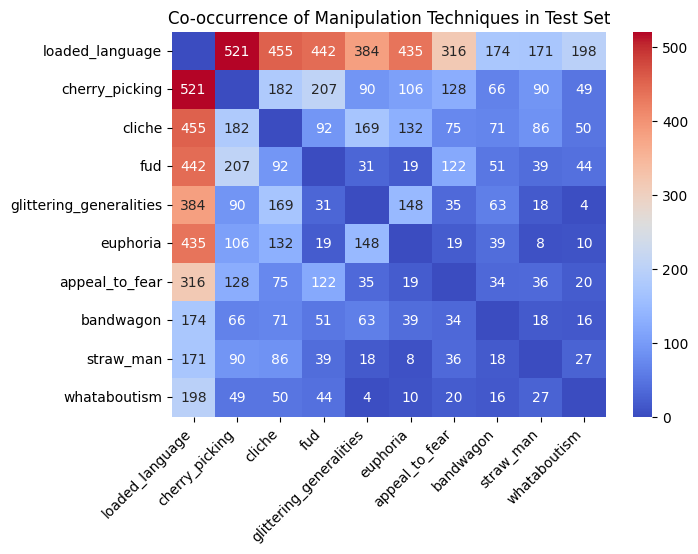

In [60]:
# Co-occurrence matrix of test
technique_list = technique_counts.keys()
binary_matrix = pd.DataFrame(0, index=df.index, columns=technique_list)

for idx, techniques in enumerate(df['techniques']):
    binary_matrix.loc[idx, techniques] = 1  # Set 1 where technique is present

co_occurrence_matrix = binary_matrix.T.dot(binary_matrix)
np.fill_diagonal(co_occurrence_matrix.values, 0)

sorted_indices = co_occurrence_matrix.sum(axis=1).sort_values(ascending=False).index
co_occurrence_matrix = co_occurrence_matrix.loc[sorted_indices, sorted_indices]

annot_matrix = co_occurrence_matrix.astype(str).values
np.fill_diagonal(annot_matrix, "")  # Replace diagonal with empty strings

plt.figure(figsize=(7, 5))
sns.heatmap(co_occurrence_matrix, annot=annot_matrix, cmap="coolwarm", fmt="s")
plt.title("Co-occurrence of Manipulation Techniques in Test Set")
plt.xticks(rotation=45, ha='right')
plt.show()

## Named Entity Recognition

In this block, we perform named-entity recognition (NER) separately on the manipulated parts of the text and the remaining text. Then we compare the results across defferent manipulation techniques separately in Ukrainian and Russian.

### Spacy setup

In [67]:
spacy.prefer_gpu()

True

In [68]:
# Download spacy models
!python -m spacy download uk_core_news_lg -q
!python -m spacy download ru_core_news_lg -q


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('uk_core_news_lg')

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_lg')


In [69]:
# Load spaCy NER models
nlp_uk = spacy.load("uk_core_news_lg")
nlp_ru = spacy.load("ru_core_news_lg")

In [70]:
# Define stopwords sets (from spaCy)
stopwords_uk = nlp_uk.Defaults.stop_words
stopwords_ru = nlp_ru.Defaults.stop_words

In [73]:
# Define a dictionary for acronym expansion (Ukrainian & Russian)
acronym_dict = {
    "сша": "сполучені штати америки",
    "лол": "дуже смішно",
    "омг": "о боже",
    "бзв": "до вашого відома",
    "незнаю": "не знаю",  # Common typo fix

    "ссср": "союз советских социалистических республик",
    "нло": "неопознанный летающий объект",
    "мчс": "министерство чрезвычайных ситуаций",
}

### Data preprocessing setup

In [74]:
def preprocess_text(text, lang):
    if lang == "ru":
        nlp = nlp_ru
        stopwords_set = stopwords_ru
    else:
        nlp = nlp_uk
        stopwords_set = stopwords_uk

    # Convert to lowercase
    text = text.lower()

    # Expand acronyms
    for acronym, expanded in acronym_dict.items():
        text = re.sub(r'\b' + re.escape(acronym) + r'\b', expanded, text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove emojis
    text = emoji.replace_emoji(text, replace='')

    # Remove extra spaces and newlines
    text = re.sub(r'\s+', ' ', text)  # Replace multiple spaces with a single space
    text = text.replace('\n', ' ')    # Replace newline characters with a space
    text = text.strip()               # Remove leading/trailing spaces

    # Process text using spaCy (tokenization & lemmatization)
    doc = nlp(text)
    processed_words = [
        token.lemma_ for token in doc if token.text not in stopwords_set and not token.is_punct
    ]

    return ' '.join(processed_words)

### Manipulative spans exploration

In [75]:
# Extract trigger words from content and preprocess them
def extract_trigger_words(row):
    content = row['content']
    trigger_spans = row['trigger_words']
    lang = row['lang']
    if trigger_spans is None:
        return []
    return [preprocess_text(content[start:end], lang) for start, end in trigger_spans]

df['extracted_trigger_words'] = df.apply(extract_trigger_words, axis=1)

In [76]:
df['extracted_trigger_words']

0       [просрали, положить куча человек, выставить на...
1                     [китаец вкрай ебнулись мирный план]
2       [сегодня ровно 6 месяц обещание ловить кретин ...
3                                                      []
4       [йти, довбойоби, розраховувати, людина розуміт...
                              ...                        
5730    [каждый раз аудитория становиться десяток милл...
5731    [ермак считать залужного политический конкурен...
5732                                              [росія]
5733                                                   []
5734                                                   []
Name: extracted_trigger_words, Length: 5735, dtype: object

In [77]:
# Perform Named Entity Recognition (NER) on extracted spans
def perform_ner(text, lang):
    if lang == "uk":
        doc = nlp_uk(text)
    elif lang == "ru":
        doc = nlp_ru(text)
    else:
        return []
    return [(ent.text, ent.label_) for ent in doc.ents]

df['ner_trigger'] = df.apply(lambda row: perform_ner(' '.join(row['extracted_trigger_words']), row['lang']) if len(row['extracted_trigger_words'])!=0 else [], axis=1)

In [78]:
df['ner_trigger']

0                               [(нато, ORG), (усэ, ORG)]
1                                                      []
2                                           [(ялта, PER)]
3                                                      []
4                                                      []
                              ...                        
5730                                                   []
5731    [(ермак, PER), (зеленского, PER), (ссо, ORG), ...
5732                                       [(росія, LOC)]
5733                                                   []
5734                                                   []
Name: ner_trigger, Length: 5735, dtype: object

In [79]:
num_non_empty_ners = df['ner_trigger'].apply(bool).sum()
print(f"Number of manipulated texts where entities where recognized: {num_non_empty_ners}")

Number of manipulated texts where entities where recognized: 2080


In [80]:
# Display top named entities in trigger spans per language
for lang in df['lang'].unique():
    print(f"Named Entities in trigger spans for {lang}:", df[df['lang']==lang]['ner_trigger'].explode().value_counts().head(10))
    print()

Named Entities in trigger spans for ru: ner_trigger
(украина, LOC)            427
(россия, LOC)             262
(всу, ORG)                149
(америка, LOC)            141
(рф, LOC)                 107
(киев, LOC)                83
(днр, LOC)                 82
(донбасс, LOC)             65
(путин, PER)               61
(сполучені штати, PER)     53
Name: count, dtype: int64

Named Entities in trigger spans for uk: ner_trigger
(україна, LOC)    459
(росія, LOC)      132
(зсу, ORG)         60
(путін, PER)       54
(рф, LOC)          52
(європа, LOC)      29
(москва, LOC)      24
(америка, LOC)     23
(крим, LOC)        22
(нато, ORG)        20
Name: count, dtype: int64

Named Entities in trigger spans for en: Series([], Name: count, dtype: int64)

Named Entities in trigger spans for et: Series([], Name: count, dtype: int64)

Named Entities in trigger spans for bg: Series([], Name: count, dtype: int64)



In [81]:
# Count most popular named entities for each language anf for each technique

# Ensure techniques and NER results are exploded into separate rows
df_exploded = df.explode('techniques').explode('ner_trigger')

# Extract entity text and type from the tuple (text, entity_type)
df_exploded[['trigger_entity_text', 'trigger_entity_type']] = pd.DataFrame(df_exploded['ner_trigger'].tolist(), index=df_exploded.index)

# Count occurrences of named entities for each technique
entity_counts = df_exploded.groupby(['lang', 'techniques', 'trigger_entity_text', 'trigger_entity_type']).size().reset_index(name='count')

# Sort by technique and count in descending order
entity_counts_sorted = entity_counts.sort_values(['lang', 'techniques', 'count'], ascending=[True, True, False])

print("\nTop 10 Named Entities per Manipulative Technique for Each Language:")
top_10_entities_per_technique_lang = entity_counts_sorted.groupby(['lang', 'techniques']).head(10)
for (lang, technique), group in top_10_entities_per_technique_lang.groupby(['lang', 'techniques']):
    print(f"\nLanguage: {lang} | Technique: {technique}")
    print(group[['trigger_entity_text', 'trigger_entity_type', 'count']].to_string(index=False))


Top 10 Named Entities per Manipulative Technique for Each Language:

Language: ru | Technique: appeal_to_fear
trigger_entity_text trigger_entity_type  count
            украина                 LOC    133
             россия                 LOC     44
            америка                 LOC     40
                всу                 ORG     32
               киев                 LOC     21
                 рф                 LOC     19
    сполучені штати                 PER     14
             европа                 LOC     13
                днр                 LOC     12
               нато                 ORG     11

Language: ru | Technique: bandwagon
trigger_entity_text trigger_entity_type  count
             россия                 LOC     39
            украина                 LOC     38
            донбасс                 LOC     19
                 рф                 LOC     17
              путин                 PER     15
                всу                 ORG     12
      

### Text witout manipulative spans exploration

In [82]:
# Extract all text except trigger words from content and preprocess it
def extract_normal_text(row):
    content = row['content']
    lang = row['lang']
    trigger_spans = row['trigger_words']
    if trigger_spans is None:
        return preprocess_text(content, lang)

    spans_to_remove = sorted(trigger_spans, key=lambda x: (x[0], x[1]))
    result = []
    last_idx = 0
    for start, end in spans_to_remove:
        result.append(content[last_idx:start])
        last_idx = end

    result.append(content[last_idx:])

    return preprocess_text(' '.join(result), lang)

df['extracted_normal_text'] = df.apply(extract_normal_text, axis=1)

In [83]:
# Perform Named Entity Recognition (NER)
df['ner_normal'] = df.apply(lambda row: perform_ner(row['extracted_normal_text'], row['lang']), axis=1)
df['ner_normal']

0                                                      []
1       [(китай, LOC), (рф, LOC), (the wall street jou...
2                                                      []
3       [(ізраїль, LOC), (the telegraph, ORG), (ємен х...
4       [(анатолій макаренко, PER), (зеленський україн...
                              ...                        
5730    [(youtubeканал, ORG), (украина, LOC), (telegra...
5731              [(цензнрнет, ORG), (юрий бутусов, PER)]
5732    [(кп чернівецький тролейбусний управління, ORG...
5733    [(нтс, ORG), (новочеркасск, LOC), (eng twitter...
5734    [(запоріжжя, LOC), (шевченківський окружний пр...
Name: ner_normal, Length: 5735, dtype: object

In [84]:
# Display top named entities per language
for lang in df['lang'].unique():
    print(f"Named Entities in normal text for {lang}:", df[df['lang']==lang]['ner_normal'].explode().value_counts().head(10))
    print()

Named Entities in normal text for ru: ner_normal
(украина, LOC)            657
(россия, LOC)             401
(рф, LOC)                 309
(всу, ORG)                253
(америка, LOC)            195
(днр, LOC)                126
(киев, LOC)               116
(сполучені штати, PER)     99
(донецк, LOC)              95
(путин, PER)               82
Name: count, dtype: int64

Named Entities in normal text for uk: ner_normal
(україна, LOC)    1795
(росія, LOC)       350
(рф, LOC)          310
(америка, LOC)     199
(зсу, ORG)         160
(київ, LOC)        132
(сбу, ORG)         107
(крим, LOC)         99
(путін, PER)        87
(єс, ORG)           84
Name: count, dtype: int64

Named Entities in normal text for en: Series([], Name: count, dtype: int64)

Named Entities in normal text for et: Series([], Name: count, dtype: int64)

Named Entities in normal text for bg: Series([], Name: count, dtype: int64)



## Sentiment analysis

In [85]:
# Download the sentiment analysis model
sentiment = pipeline("text-classification", model="tabularisai/multilingual-sentiment-analysis", return_all_scores=True, truncation=True)

Device set to use mps:0


In [86]:
# Create separate dataframe
sentiments_df = pd.DataFrame()
sentiments_df['content'] = df['content']
sentiments_df['techniques'] = df['techniques']

In [ ]:
# Perform sentiment analysis on the content
sentiments_df['sentiment'] = sentiments_df['content'].apply(lambda x: sentiment(x)[0])

In [ ]:
sentiments_df['sentiment'][0]

[{'label': 'Very Negative', 'score': 0.3541603684425354},
 {'label': 'Negative', 'score': 0.24642419815063477},
 {'label': 'Neutral', 'score': 0.3125979006290436},
 {'label': 'Positive', 'score': 0.05391770973801613},
 {'label': 'Very Positive', 'score': 0.03289973363280296}]

In [ ]:
# Convert sentiments into separate columns
sep_df = sentiments_df['sentiment'].apply(lambda sent: {s['label']: s['score'] for s in sent})
sep_df = pd.DataFrame(sep_df.tolist())

# Merge with original DataFrame
sentiments_df = pd.concat([sentiments_df.drop(columns=['sentiment']), sep_df], axis=1)

In [ ]:
sentiments_df.head()

,content,techniques,Very Negative,Negative,Neutral,Positive,Very Positive
0,Новий огляд мапи DeepState від російського вій...,"[euphoria, loaded_language]",0.354160,0.246424,0.312598,0.053918,0.032900
1,Недавно 95 квартал жёстко поглумился над русск...,"[loaded_language, cherry_picking]",0.221012,0.317355,0.357985,0.078564,0.025083
2,🤩\nТим часом йде евакуація Бєлгородського авто...,"[loaded_language, euphoria]",0.282586,0.301587,0.321475,0.063491,0.030860
3,В Україні найближчим часом мають намір посилит...,None,0.062255,0.076972,0.527887,0.238673,0.094212
4,"Расчёты 122-мм САУ 2С1 ""Гвоздика"" 132-й бригад...",[loaded_language],0.043830,0.045117,0.093822,0.334327,0.482904


In [ ]:
# Explode the DataFrame to have one row per technique
sentiments_df_exploded = sentiments_df.explode('techniques')

In [ ]:
# Calculate average sentiment scores for texts without manipulation
sentiments_df_exploded[sentiments_df_exploded['techniques'].isna()].drop(['content', 'techniques'], axis=1).mean()

Very Negative    0.266327
Negative         0.147420
Neutral          0.231119
Positive         0.173162
Very Positive    0.181972
dtype: float64

In [ ]:
# Calculate average sentiment for each manipulation technique
technique_sentiment = sentiments_df_exploded.drop('content', axis=1).groupby('techniques').mean()
technique_sentiment

,Very Negative,Negative,Neutral,Positive,Very Positive
techniques,,,,,
appeal_to_fear,0.402941,0.202210,0.217873,0.099474,0.077501
bandwagon,0.357424,0.151895,0.188585,0.118362,0.183734
cherry_picking,0.349050,0.198051,0.245526,0.106682,0.100691
cliche,0.337557,0.164703,0.205186,0.121317,0.171237
euphoria,0.335825,0.140931,0.181348,0.135661,0.206235
fud,0.379746,0.214999,0.245318,0.091975,0.067962
glittering_generalities,0.251076,0.094636,0.141456,0.161695,0.351136
loaded_language,0.368147,0.173808,0.201285,0.115836,0.140924
straw_man,0.380697,0.201332,0.241533,0.095366,0.081072


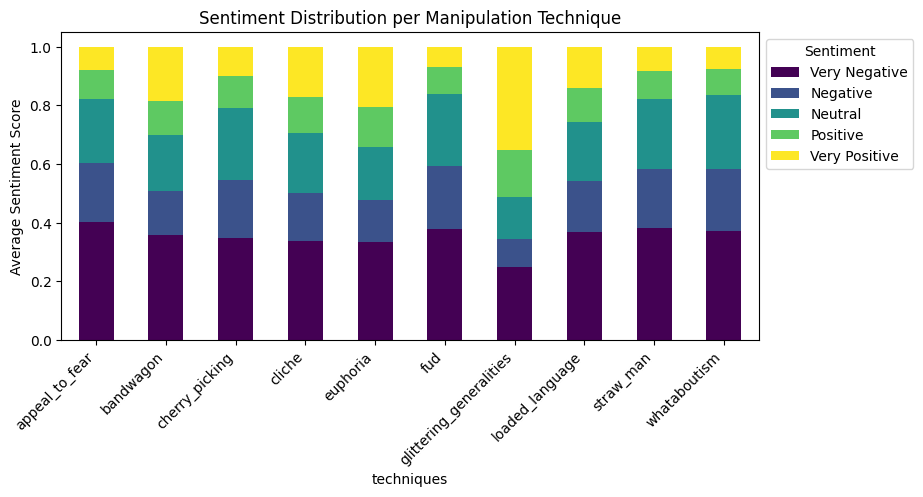

In [ ]:
technique_sentiment.plot(kind='bar', stacked=True, colormap='viridis', figsize=(9, 4))
plt.title("Sentiment Distribution per Manipulation Technique")
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Sentiment", bbox_to_anchor=(1, 1))
plt.show()